# Segmentation-free co-localization analysis of transcript coordinates (experimental)

**Author:** Jun Inamo (juninamo@keio.jp)

Imaging-based platforms such as Xenium record the coordinates of every transcript. Cell-level analyses (`nhood_enrichment()`, `cooccur_local()`) depend on cell segmentation and on assigning each cell a type, and errors in either step propagate into the co-localization estimate. This tutorial works on the **transcripts directly**, without segmentation.

**The idea**

* Transcripts of each gene form a point pattern. The **cross pair correlation** $g_{AB}(r)$ between gene sets A and B (e.g. marker genes of two cell types) is the ratio of the number of A–B transcript pairs found at distance $r$ to the number expected if the two patterns were independent. $\log g_{AB}(r) > 0$ means co-localization at that distance.
* The **relative** version divides by the pair correlation of all transcripts. This equals the observed / expected ratio when gene labels are permuted over the fixed transcript positions, the same logic as the label permutation behind `log2_oe` in `nhood_enrichment()`, but continuous in distance and free of segmentation.
* A **model-based** version fits a log-Gaussian Cox process in which each gene's log-intensity is a mixture of a shared *cellularity* field and $K$ spatial factors. Each factor is a Gaussian process approximated with **random Fourier features**, following the random feature latent variable model of Gundersen, Zhang & Engelhardt (AISTATS 2021), with the spatial coordinates as inputs. The model provides a **composition** pair correlation, which removes the cellularity field, and interpretable spatial scales (length scales).

These functions are **experimental**: the interface may change, and the model is fitted by MAP in R (a JAX implementation is needed for whole Xenium sections).

**Contents**

1. Setup
2. A simulated tissue with known truth
3. The random-feature model
4. Case-control comparison
5. Real data: Xenium mouse brain
6. Practical guidance

## 1. Setup

In [1]:
suppressPackageStartupMessages(suppressWarnings({
  if (file.exists("../DESCRIPTION")) {
    devtools::load_all("..", quiet = TRUE)
  } else {
    library(spatialCooccur)
  }
  library(ggplot2)
  library(patchwork)
}))
options(repr.plot.width = 10, repr.plot.height = 5, repr.plot.res = 130)
n_cores <- max(1, min(8, parallel::detectCores() - 1))

group_cols <- c(control = "#2a78d6", case = "#eb6834")
series_cols <- c("#2a78d6", "#eb6834", "#1baf7a", "#eda100")
theme_tut <- theme_minimal(base_size = 12) +
  theme(panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold"),
        plot.title.position = "plot")

## 2. A simulated tissue with known truth

`simulate_transcripts()` draws transcripts from a multivariate log-Gaussian Cox process. There are three gene sets (A, B, C; five genes each). Each set has its own "territory" field, all genes share a slowly varying cellularity field, and sets **A and B share a niche field** (length scale 20 µm), so they co-localize. The fields are generated exactly by FFT, *not* with random features, so the model below is not tested on data from its own approximation.

[1] 109557

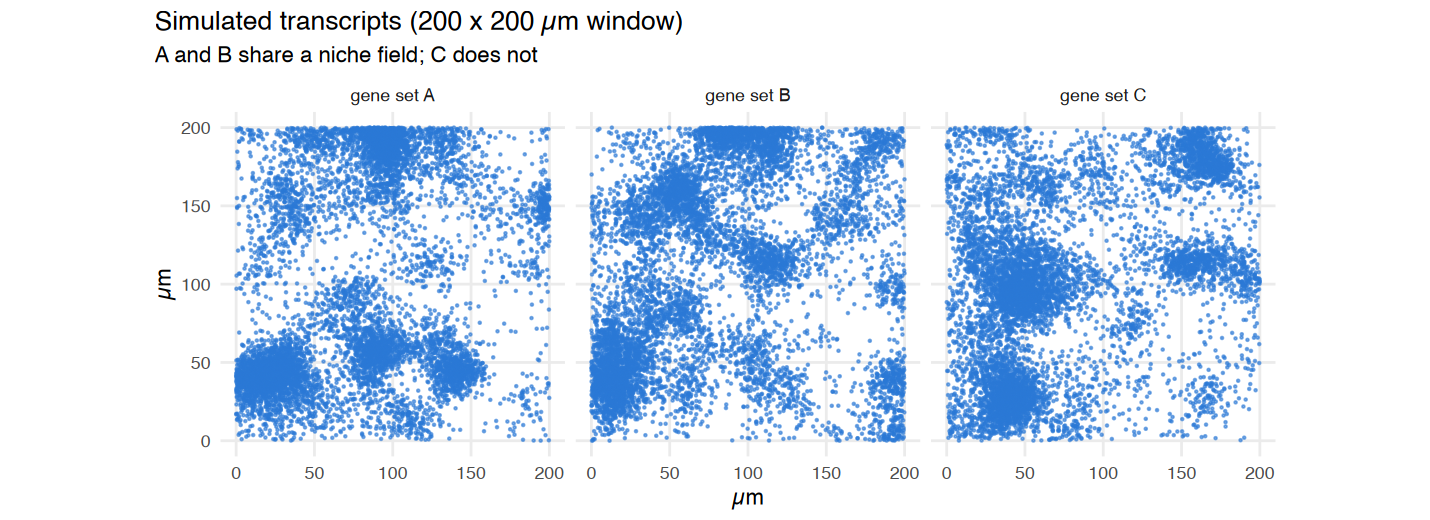

In [2]:
tx <- simulate_transcripts(size = 400, rate = 0.02, coloc = c(A = 0.8, B = 0.8), seed = 101)
truth <- attr(tx, "truth")
sets <- split(truth$genes, truth$set_of)
nrow(tx)

options(repr.plot.width = 11, repr.plot.height = 4)
ggplot(subset(tx, x < 200 & y < 200), aes(x, y)) +
  geom_point(size = 0.15, color = "#2a78d6", alpha = 0.6) +
  facet_wrap(~ gene_set, labeller = labeller(gene_set = function(s) paste("gene set", s))) +
  coord_equal() +
  labs(title = "Simulated transcripts (200 x 200 µm window)",
       subtitle = "A and B share a niche field; C does not", x = "µm", y = "µm") +
  theme_tut

`bin_transcripts()` counts transcripts per gene in square bins (4 µm here). `pcf_cross()` estimates $g_{AB}(r)$ from the binned counts with FFTs and edge correction. Compare it with the closed-form truth for the relative pair correlation:

<binned_transcripts> 100 x 100 bins of 4 (10000 in tissue), 15 genes, 109557 transcripts

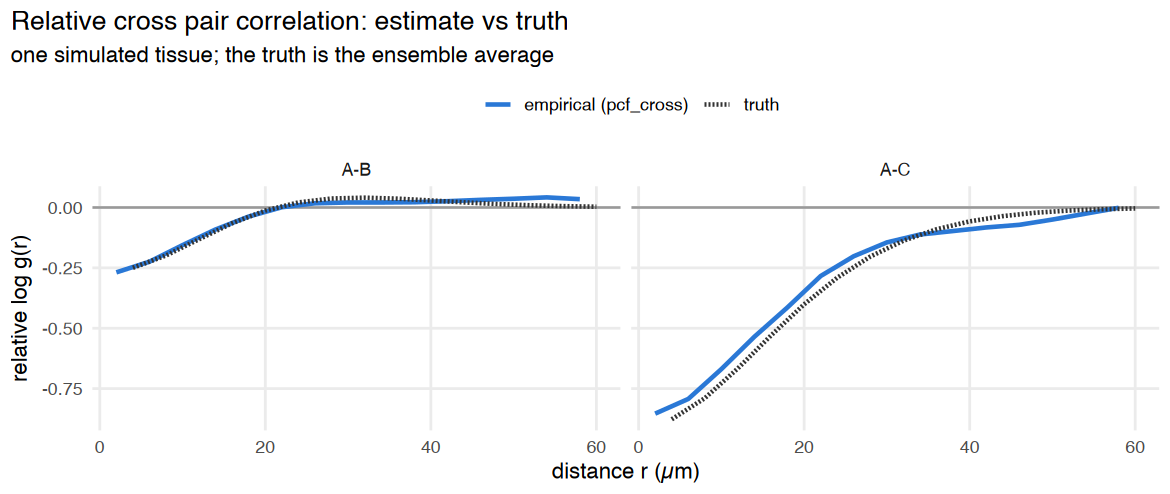

In [3]:
b <- bin_transcripts(tx, bin_size = 4, tissue_radius = Inf)
b

r_grid <- seq(4, 60, by = 4)
curves <- do.call(rbind, lapply(list(c("A", "B"), c("A", "C")), function(p) {
  e <- pcf_cross(b, sets[[p[1]]], sets[[p[2]]], r_max = 60, relative = TRUE)
  rbind(data.frame(pair = paste(p, collapse = "-"), r = e$r, log_g = e$log_g, source = "empirical (pcf_cross)"),
        data.frame(pair = paste(p, collapse = "-"), r = r_grid, source = "truth",
                   log_g = lgcp_true_pair_correlation(truth, p[1], p[2], r_grid, "relative")$log_g))
}))

options(repr.plot.width = 9, repr.plot.height = 3.8)
ggplot(curves, aes(r, log_g, color = source, linetype = source)) +
  geom_hline(yintercept = 0, color = "grey60") +
  geom_line(linewidth = 0.9) +
  facet_wrap(~ pair) +
  scale_color_manual(values = c("empirical (pcf_cross)" = "#2a78d6", truth = "grey20")) +
  labs(title = "Relative cross pair correlation: estimate vs truth",
       subtitle = "one simulated tissue; the truth is the ensemble average",
       x = "distance r (µm)", y = "relative log g(r)", color = NULL, linetype = NULL) +
  theme_tut + theme(legend.position = "top")

The estimate follows the truth. A single tissue fluctuates around the ensemble value, because territories are only realized a few dozen times in a 400 µm window. In a group comparison, this fluctuation becomes between-sample variance.

A–B is negative at short range even though A and B *co-localize*. The relative pair correlation compares A–B pairs with **all** transcript pairs, and here each gene set clusters much more strongly with itself than with the other sets. The same happens with `log2_oe` when every cell type is spatially clustered. What matters for a case-control study is how this value **changes** between groups (section 4).

## 3. The random-feature model

`fit_spatial_rff()` fits

$$\log\mu_{bj} = \log a + \alpha_j + \sigma_0 f_0(u_b) + \sum_{k=1}^K L_{jk} f_k(u_b), \qquad f_k(u) = \phi_{\ell_k}(u)^\top\gamma_k,$$

with negative-binomial counts $y_{bj}$ in bin $b$ for gene $j$. Here $f_0$ is the cellularity field, and $\phi_\ell(u) = M^{-1/2}[\cos(\Omega u/\ell), \sin(\Omega u/\ell)]$ are random Fourier features of an RBF kernel with length scale $\ell$. Because the length scale enters through $\Omega u/\ell$, all parameters, including the $\ell_k$, have closed-form gradients.

In [4]:
t0 <- Sys.time()
fit <- fit_spatial_rff(b, n_factors = 4, lengthscales = c(10, 15, 25, 50),
                       n_features = 64, max_iter = 300)
Sys.time() - t0
fit
round(fit$L, 2)[c("A_1", "B_1", "C_1"), ]

Time difference of 46.0359 secs

<spatial_rff_fit> nb model, 15 genes, 10000 bins, 4 factors
  factor length scales: 10.6, 14.5, 23.2, 58.2 
  cellularity field: sd 0.18, length scale 92.3
  convergence: 1 (NEW_X)

,factor1,factor2,factor3,factor4
A_1,-0.79,0.18,1.29,0.92
B_1,-0.87,-0.80,0.49,0.56
C_1,0.34,0.04,-0.36,0.32


`rff_pair_correlation()` turns the fit into pair correlations. `type = "composition"` removes the cellularity field. `method = "intensity"` (the default) applies the same FFT estimator to the fitted intensity surfaces, a denoised empirical estimate with no Gaussian assumption. `method = "gaussian"` uses the closed form $\exp(C_{AB}(r))$, which is exact only if the log-intensities really are Gaussian. The truth here *is* Gaussian, so both can be checked:

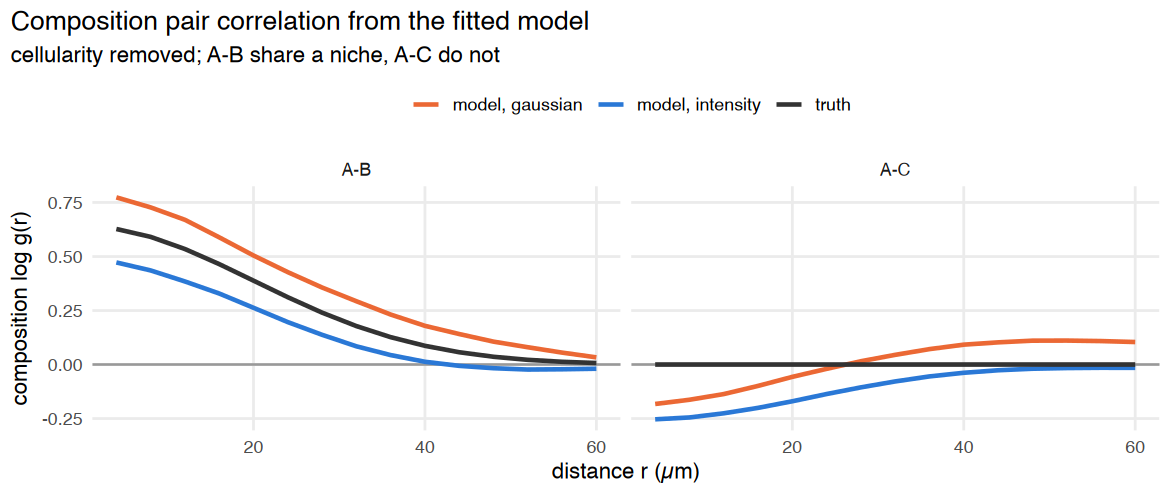

In [5]:
comp <- do.call(rbind, lapply(list(c("A", "B"), c("A", "C")), function(p) {
  f <- function(m) rff_pair_correlation(fit, sets[[p[1]]], sets[[p[2]]], r_grid, "composition", method = m)$log_g
  rbind(data.frame(pair = paste(p, collapse = "-"), r = r_grid, source = "model, intensity", log_g = f("intensity")),
        data.frame(pair = paste(p, collapse = "-"), r = r_grid, source = "model, gaussian", log_g = f("gaussian")),
        data.frame(pair = paste(p, collapse = "-"), r = r_grid, source = "truth",
                   log_g = lgcp_true_pair_correlation(truth, p[1], p[2], r_grid, "composition")$log_g))
}))

ggplot(comp, aes(r, log_g, color = source)) +
  geom_hline(yintercept = 0, color = "grey60") +
  geom_line(linewidth = 0.9) +
  facet_wrap(~ pair) +
  scale_color_manual(values = c("model, intensity" = "#2a78d6", "model, gaussian" = "#eb6834", truth = "grey20")) +
  labs(title = "Composition pair correlation from the fitted model",
       subtitle = "cellularity removed; A-B share a niche, A-C do not",
       x = "distance r (µm)", y = "composition log g(r)", color = NULL) +
  theme_tut + theme(legend.position = "top")

Both methods find the A–B co-localization. For A–C (true value 0), this single tissue gives slightly negative values. Across repeated simulations the A–C estimate averages about 0 (−0.03 ± 0.25 at 4 µm over 4 seeds), so this is sample-to-sample variation. The intensity method is shrunk towards 0 at short range, because the MAP fields are smoother than the truth, so it is conservative. The Gaussian method slightly overshoots here, and on real tissue (section 5) it is badly miscalibrated. `"intensity"` is therefore the default.

## 4. Case-control comparison

`simulate_transcripts_groups()` simulates 6 control and 6 case samples with **8 gene sets** (closer to a real panel with many cell types). The niche loading of A and B is 0.3 in controls and 0.9 in cases, so A–B co-localize more strongly in cases. `colocalization_per_sample()` returns one row per sample × pair × distance, ready for `compare_groups()` with `pair_keys = c("cluster_i", "cluster_j", "r")`.

In [6]:
gs8 <- LETTERS[1:8]
cc <- simulate_transcripts_groups(6, group_coloc = list(control = 0.3, case = 0.9),
                                  gene_sets = gs8, n_genes_per_set = 3,
                                  size = 300, rate = 0.03, seed = 7)
sets8 <- with(unique(cc[, c("gene", "gene_set")]), split(gene, gene_set))
pairs <- list(c("A", "B"), c("A", "C"))
r_test <- c(8, 16, 32)

t0 <- Sys.time()
emp_cc <- colocalization_per_sample(cc, "sample_id", "group", "patient", sets8, pairs, r_test,
                                    method = "empirical", relative = TRUE, tissue_radius = Inf)
mod_cc <- colocalization_per_sample(cc, "sample_id", "group", "patient", sets8, pairs, r_test,
                                    method = "model", model_type = "composition", n_cores = n_cores,
                                    tissue_radius = Inf, n_factors = 5,
                                    lengthscales = c(10, 15, 25, 50, 100), max_iter = 300)
Sys.time() - t0

test_all <- function(d, label) {
  res <- compare_groups(d, value = "log_g", method = "wilcox", ref_group = "control",
                        pair_keys = c("cluster_i", "cluster_j", "r"))
  data.frame(score = label, pair = paste(res$cluster_i, res$cluster_j, sep = "-"), r = res$r,
             effect = round(res$effect, 2), p = signif(res$p, 2), padj = signif(res$padj, 2))
}
cc_res <- rbind(test_all(emp_cc, "relative (empirical)"), test_all(mod_cc, "composition (model)"))
cc_res[order(cc_res$score, cc_res$pair, cc_res$r), ]

Time difference of 48.88825 secs

,score,pair,r,effect,p,padj
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
7,composition (model),A-B,8,0.90,0.0022,0.0065
8,composition (model),A-B,16,0.76,0.0022,0.0065
9,composition (model),A-B,32,0.33,0.0260,0.0520
11,composition (model),A-C,8,0.00,0.9400,1.0000
12,composition (model),A-C,16,0.01,1.0000,1.0000
10,composition (model),A-C,32,0.04,0.5900,0.8800
1,relative (empirical),A-B,8,0.46,0.0022,0.0065
2,relative (empirical),A-B,16,0.41,0.0022,0.0065
4,relative (empirical),A-B,32,0.19,0.0650,0.0780


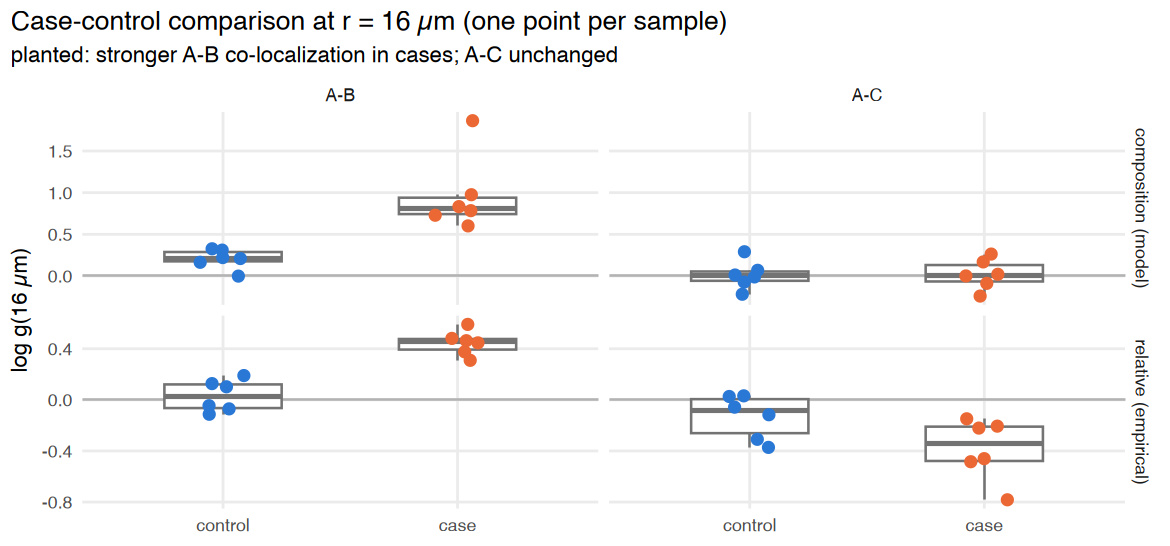

In [7]:
plot_df <- rbind(data.frame(emp_cc, score = "relative (empirical)"),
                 data.frame(mod_cc, score = "composition (model)"))
plot_df <- subset(plot_df, r == 16)
plot_df$group <- factor(plot_df$group, levels = c("control", "case"))
plot_df$pair <- paste(plot_df$cluster_i, plot_df$cluster_j, sep = "-")

options(repr.plot.width = 9, repr.plot.height = 4.2)
ggplot(plot_df, aes(group, log_g, color = group)) +
  geom_hline(yintercept = 0, color = "grey70") +
  geom_boxplot(outlier.shape = NA, width = 0.5, color = "grey45") +
  geom_point(position = position_jitter(width = 0.1, seed = 1), size = 2.4) +
  facet_grid(score ~ pair, scales = "free_y") +
  scale_color_manual(values = group_cols, guide = "none") +
  labs(title = "Case-control comparison at r = 16 µm (one point per sample)",
       subtitle = "planted: stronger A-B co-localization in cases; A-C unchanged",
       x = NULL, y = "log g(16 µm)") +
  theme_tut

Both scores detect the planted A–B change. The relative score also shows a small A–C *decrease*: when A pairs more with B, it pairs relatively less with everything else. As with `log2_oe`, read such depletion as a consequence of the main change.

### Robustness to differences in cellularity

Tissue from cases is often more cellular or more heterogeneous. In the next simulation **co-localization is identical** in both groups, but cellularity varies more in cases (`density_sd` 0.8 vs 0.3). A good score must not call a difference here.

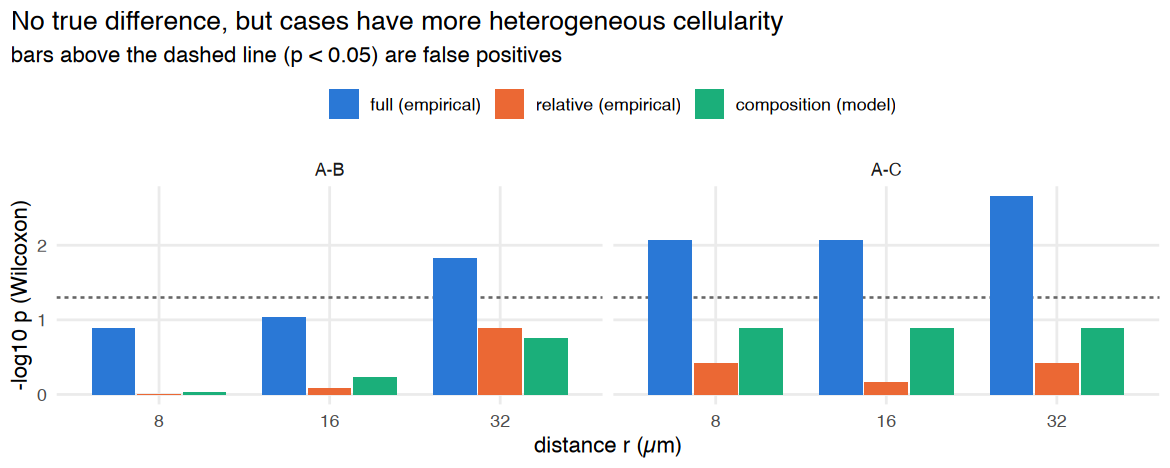

In [8]:
a <- simulate_transcripts_groups(6, group_coloc = list(control = 0.6), gene_sets = gs8, n_genes_per_set = 3,
                                 size = 300, rate = 0.03, density_sd = 0.3, seed = 8)
b2 <- simulate_transcripts_groups(6, group_coloc = list(case = 0.6), gene_sets = gs8, n_genes_per_set = 3,
                                  size = 300, rate = 0.03, density_sd = 0.8, seed = 9)
null_cc <- rbind(a, b2)

null_scores <- list(
  "full (empirical)" = colocalization_per_sample(null_cc, "sample_id", "group", "patient", sets8, pairs, r_test,
                                                 relative = FALSE, tissue_radius = Inf),
  "relative (empirical)" = colocalization_per_sample(null_cc, "sample_id", "group", "patient", sets8, pairs, r_test,
                                                     relative = TRUE, tissue_radius = Inf),
  "composition (model)" = colocalization_per_sample(null_cc, "sample_id", "group", "patient", sets8, pairs, r_test,
                                                    method = "model", n_cores = n_cores, tissue_radius = Inf,
                                                    n_factors = 5, lengthscales = c(10, 15, 25, 50, 100),
                                                    max_iter = 300))
null_res <- do.call(rbind, lapply(names(null_scores), function(s) test_all(null_scores[[s]], s)))
null_res$score <- factor(null_res$score, levels = names(null_scores))

options(repr.plot.width = 9, repr.plot.height = 3.6)
ggplot(null_res, aes(factor(r), -log10(p), fill = score)) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "grey40") +
  geom_col(position = position_dodge(width = 0.8), width = 0.75) +
  facet_wrap(~ pair) +
  scale_fill_manual(values = setNames(series_cols[1:3], names(null_scores))) +
  labs(title = "No true difference, but cases have more heterogeneous cellularity",
       subtitle = "bars above the dashed line (p < 0.05) are false positives",
       x = "distance r (µm)", y = "-log10 p (Wilcoxon)", fill = NULL) +
  theme_tut + theme(legend.position = "top")

The **full** pair correlation calls differences that are only cellularity. The **relative** and **composition** scores stay calibrated. This is the continuous counterpart of the lesson from the case-control tutorial, where z-scores tracked image size while `log2_oe` did not.

> With very few cell types (e.g. 3 gene sets, two of which co-localize) the shared niche is hard to tell apart from the cellularity field, and `composition` can still give false positives. In that case, fit with `offset = "smoothed_total"` and `offset_genes` set to broadly expressed reference genes that are not part of the tested pair.

## 5. Real data: Xenium mouse brain

We use the public 10x Genomics dataset *Xenium FF Mouse Brain Coronal Subset (CTX + HP)* (248-gene panel). Only the transcript table is needed (183 MB). It is downloaded once into the user cache directory. `read_xenium_transcripts()` handles older outputs that store gene names as binary, filters on `qv >= 20`, and drops control probes.

In [9]:
cache <- tools::R_user_dir("spatialCooccur", "cache")
dir.create(cache, recursive = TRUE, showWarnings = FALSE)
pq <- file.path(cache, "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_transcripts.parquet")
if (!file.exists(pq)) {
  options(timeout = 3600)
  download.file(paste0("https://cf.10xgenomics.com/samples/xenium/1.0.2/",
                       "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP/",
                       "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_transcripts.parquet"),
                pq, mode = "wb")
}
xtx <- read_xenium_transcripts(pq)
dim(xtx)
length(unique(xtx$gene))

[1] 9447344       7

[1] 248

Marker gene sets for nine brain cell types, all in the panel:

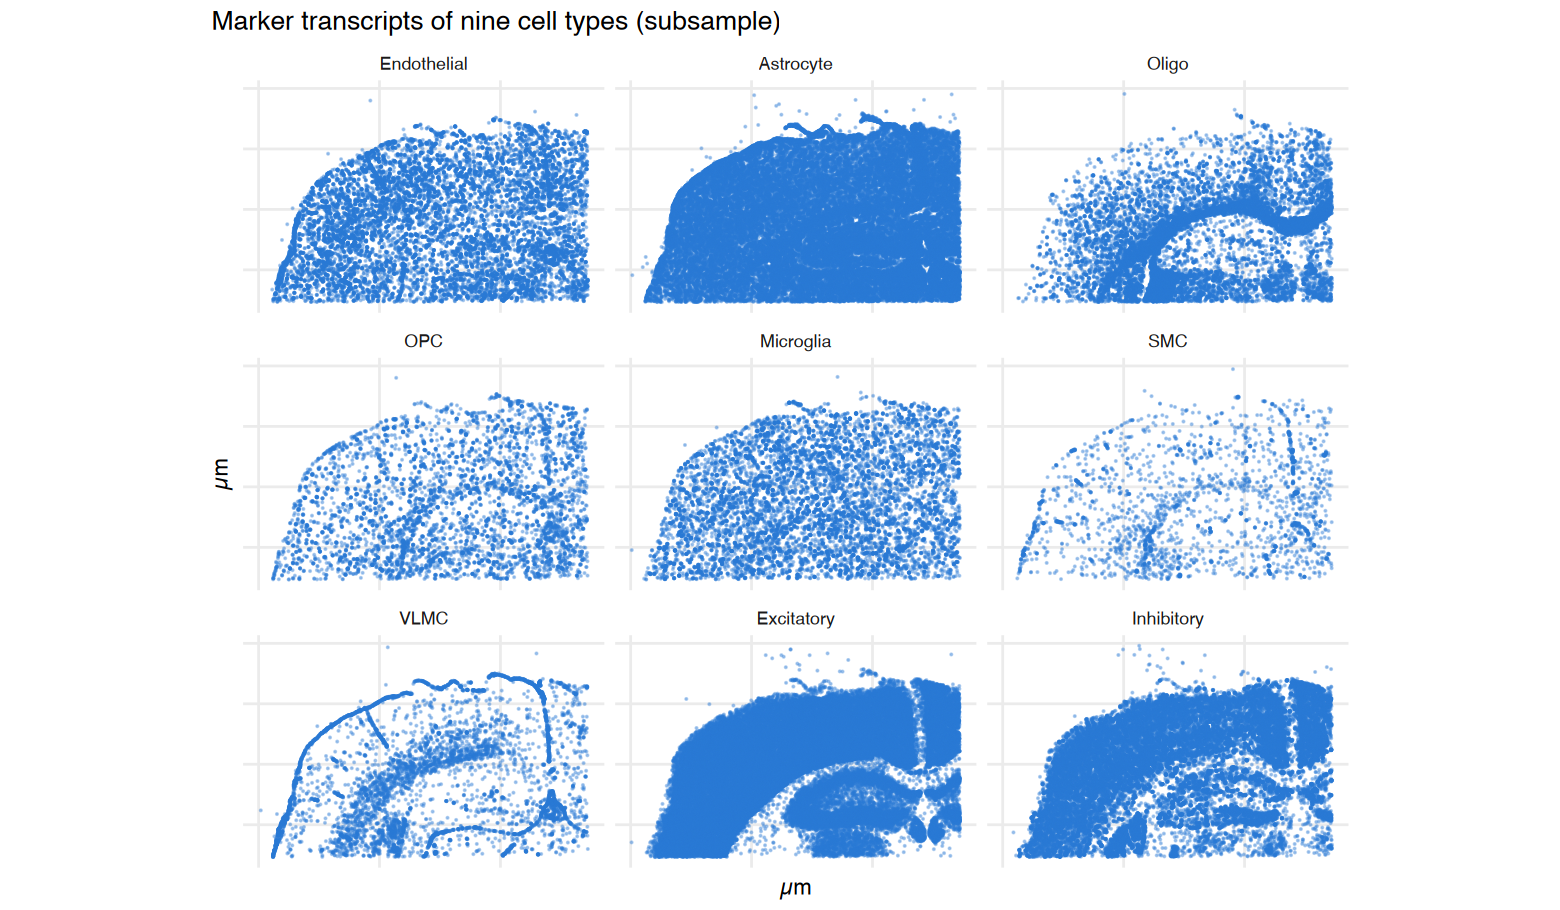

In [10]:
brain_sets <- list(
  Endothelial = c("Cldn5", "Pecam1", "Kdr", "Emcn", "Adgrl4", "Fgd5", "Cd93", "Nostrin"),
  Astrocyte   = c("Aqp4", "Gfap", "Slc39a12", "Acsbg1", "Ntsr2"),
  Oligo       = c("Opalin", "Gjc3", "Sox10"),
  OPC         = c("Pdgfra", "Gpr17"),
  Microglia   = c("Siglech", "Trem2", "Laptm5", "Cd53", "Ikzf1"),
  SMC         = c("Acta2", "Carmn"),
  VLMC        = c("Dcn", "Col1a1", "Col6a1", "Fmod"),
  Excitatory  = c("Slc17a7", "Neurod6", "Satb2"),
  Inhibitory  = c("Gad1", "Gad2", "Sst", "Pvalb", "Vip", "Lamp5"))
set_of <- setNames(rep(names(brain_sets), lengths(brain_sets)), unlist(brain_sets))

set.seed(1)
mk <- xtx[xtx$gene %in% names(set_of), ]
mk <- mk[sample(nrow(mk), 250000), ]
mk$cell_type <- factor(set_of[mk$gene], levels = names(brain_sets))

options(repr.plot.width = 12, repr.plot.height = 7)
ggplot(mk, aes(x, y)) +
  geom_point(size = 0.03, color = "#2a78d6", alpha = 0.35) +
  facet_wrap(~ cell_type, ncol = 3) +
  coord_equal() + scale_y_reverse() +
  labs(title = "Marker transcripts of nine cell types (subsample)",
       x = "µm", y = "µm") +
  theme_tut + theme(axis.text = element_blank())

Bin the whole section (4 µm bins, about 1.2 million bins) and compute the relative pair correlation for every pair of cell types. The pair correlation of all transcripts is computed once and reused.

In [11]:
t0 <- Sys.time()
xb <- bin_transcripts(xtx, bin_size = 4)
xb
tt <- pcf_cross(xb, xb$genes, xb$genes, r_max = 90)
nm <- names(brain_sets)
xres <- list()
for (i in seq_along(nm)) for (j in i:length(nm)) {
  p <- pcf_cross(xb, brain_sets[[nm[i]]], brain_sets[[nm[j]]], r_max = 90)
  xres[[length(xres) + 1]] <- data.frame(a = nm[i], b = nm[j], r = p$r, log_g_rel = p$log_g - tt$log_g)
}
xres <- do.call(rbind, xres)
# values at r = 12 µm (annulus midpoints are 2, 6, 10, ... µm, so interpolate)
xres12 <- do.call(rbind, lapply(split(xres, paste(xres$a, xres$b)), function(d)
  data.frame(a = d$a[1], b = d$b[1], r = 12, log_g_rel = approx(d$r, d$log_g_rel, xout = 12)$y)))
Sys.time() - t0

<binned_transcripts> 1361 x 882 bins of 4 (922805 in tissue), 248 genes, 9447344 transcripts

Time difference of 1.399758 mins

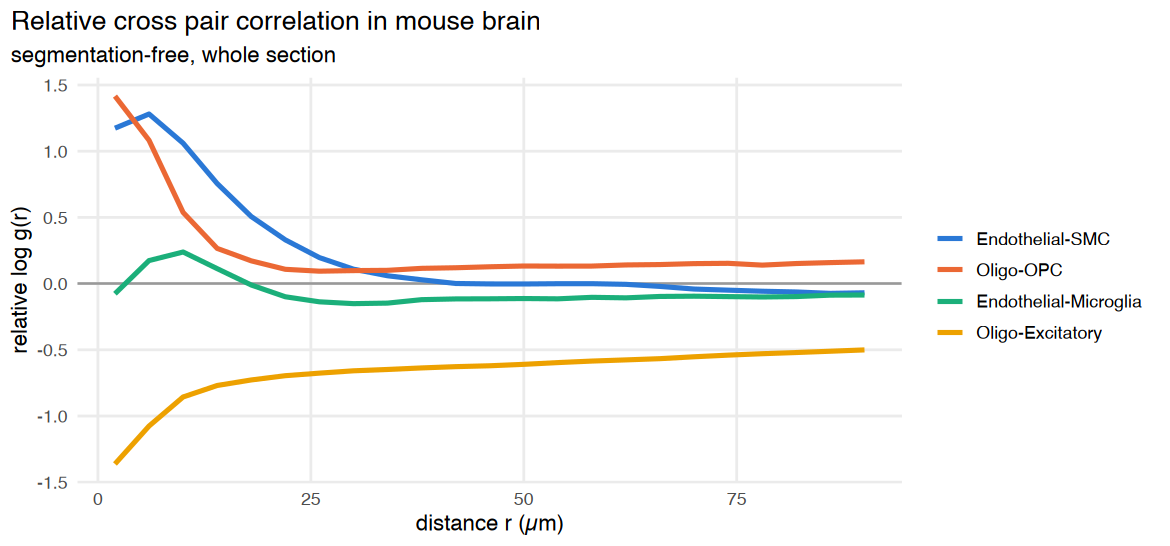

In [12]:
show <- rbind(
  data.frame(pair = "Endothelial-SMC",  subset(xres, a == "Endothelial" & b == "SMC")),
  data.frame(pair = "Oligo-OPC",        subset(xres, a == "Oligo" & b == "OPC")),
  data.frame(pair = "Endothelial-Microglia", subset(xres, a == "Endothelial" & b == "Microglia")),
  data.frame(pair = "Oligo-Excitatory", subset(xres, a == "Oligo" & b == "Excitatory")))
show <- show[is.finite(show$log_g_rel), ]
show$pair <- factor(show$pair, levels = unique(show$pair))

options(repr.plot.width = 9, repr.plot.height = 4.2)
ggplot(show, aes(r, log_g_rel, color = pair)) +
  geom_hline(yintercept = 0, color = "grey60") +
  geom_line(linewidth = 1) +
  scale_color_manual(values = setNames(series_cols, levels(show$pair))) +
  labs(title = "Relative cross pair correlation in mouse brain",
       subtitle = "segmentation-free, whole section",
       x = "distance r (µm)", y = "relative log g(r)", color = NULL) +
  theme_tut + theme(legend.position = "right")

The curves match known anatomy: vascular smooth muscle sits on endothelium, OPCs sit among oligodendrocytes, and oligodendrocytes (white matter) are segregated from excitatory neurons (grey matter) out to more than 80 µm. The heatmap shows all pairs at r = 12 µm, about one cell-to-cell distance:

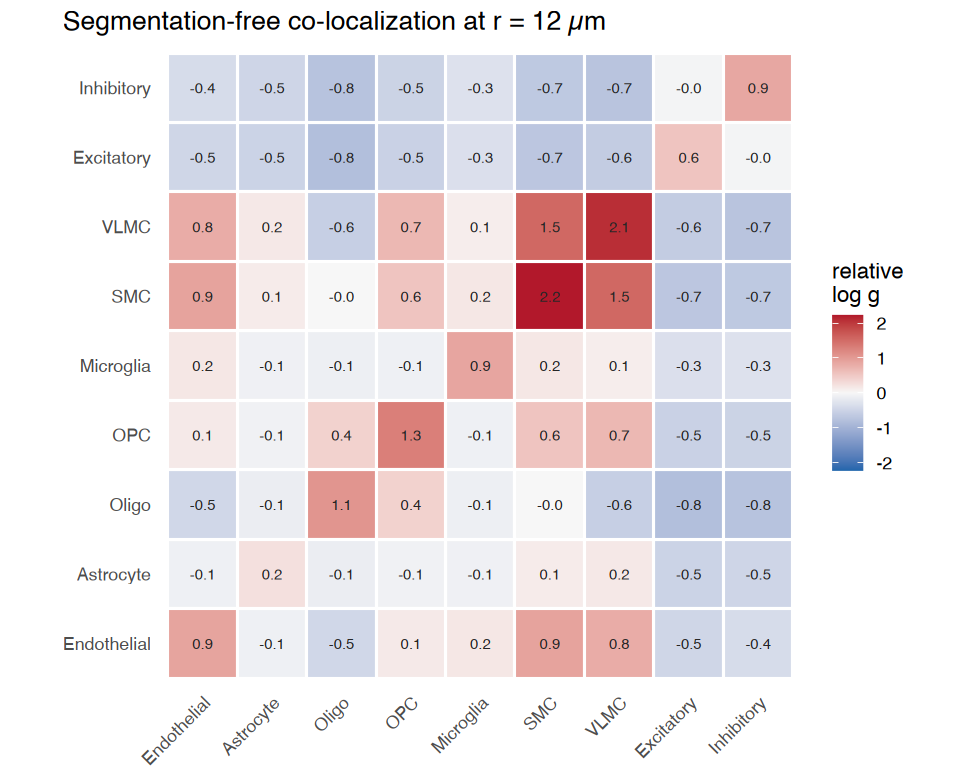

In [13]:
h12 <- xres12
h12 <- rbind(h12, transform(h12[h12$a != h12$b, ], a = b, b = a))
h12$a <- factor(h12$a, levels = nm); h12$b <- factor(h12$b, levels = nm)
lim <- max(abs(h12$log_g_rel))

options(repr.plot.width = 7.5, repr.plot.height = 6)
ggplot(h12, aes(a, b, fill = log_g_rel)) +
  geom_tile(color = "white", linewidth = 0.6) +
  geom_text(aes(label = sprintf("%.1f", log_g_rel)), size = 2.8, color = "grey15") +
  scale_fill_gradient2(low = "#2166AC", mid = "grey97", high = "#B2182B", midpoint = 0,
                       limits = c(-lim, lim), name = "relative\nlog g") +
  coord_equal() +
  labs(title = "Segmentation-free co-localization at r = 12 µm", x = NULL, y = NULL) +
  theme_tut + theme(axis.text.x = element_text(angle = 45, hjust = 1), panel.grid = element_blank())

### Agreement with the segmentation-based analysis

The same dataset comes with Xenium's cell segmentation (`cell_id`). We assign each cell the cell type whose markers dominate its transcripts, run `nhood_enrichment()` on the cell centroids, and compare its `log2_oe` with the segmentation-free relative log g for every pair.

In [14]:
seg <- xtx[xtx$cell_id != -1, ]
cent <- aggregate(cbind(x, y) ~ cell_id, data = seg, FUN = mean)
mk_all <- seg[seg$gene %in% names(set_of), ]
tab <- as.matrix(table(mk_all$cell_id, factor(set_of[mk_all$gene], levels = nm)))
score <- sweep(tab, 2, lengths(brain_sets)[colnames(tab)], "/")
top <- colnames(score)[max.col(score, ties.method = "first")]
clear <- rowSums(tab) >= 3 & apply(score, 1, function(v) { s <- sort(v, TRUE); s[1] >= 2 * s[2] })
ct <- setNames(ifelse(clear, top, "Other"), rownames(tab))
cells <- cent[as.character(cent$cell_id) %in% names(ct), ]
cells$cell_type <- factor(ct[as.character(cells$cell_id)], levels = c(nm, "Other"))
rownames(cells) <- paste0("c", cells$cell_id)
table(cells$cell_type)

ne <- nhood_enrichment(cells, cluster_key = "cell_type", neighbors.k = 10, n_perms = 200, n_jobs = 1, seed = 1)
lo <- ne$log2_oe; dimnames(lo) <- lapply(dimnames(lo), function(v) sub("^Cluster", "", v))
h12u <- xres12
h12u$log2_oe <- mapply(function(a, b) (lo[a, b] + lo[b, a]) / 2, h12u$a, h12u$b)
h12u$kind <- ifelse(h12u$a == h12u$b, "same type", "different types")
rho <- cor(h12u$log_g_rel, h12u$log2_oe, method = "spearman")
rho


Endothelial   Astrocyte       Oligo         OPC   Microglia         SMC 
        623        4353        2827         688         523         288 
       VLMC  Excitatory  Inhibitory       Other 
        437       13935        1656       11098 

[1] 0.7690382

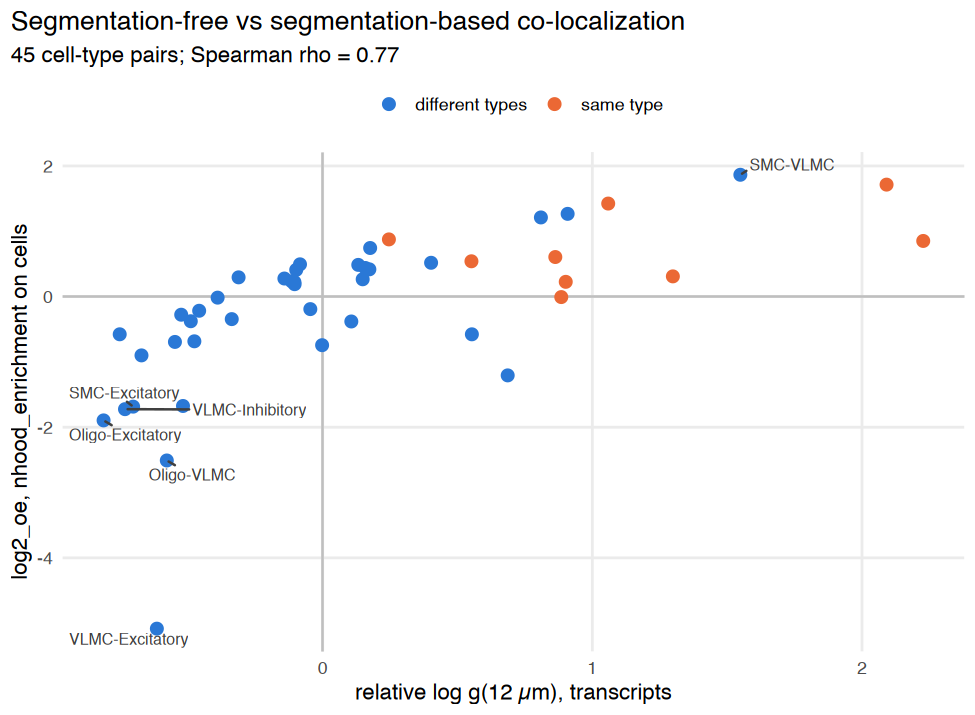

In [15]:
lab <- subset(h12u, kind == "different types")
lab <- lab[order(-abs(lab$log2_oe)), ][1:6, ]

options(repr.plot.width = 7.5, repr.plot.height = 5.5)
ggplot(h12u, aes(log_g_rel, log2_oe, color = kind)) +
  geom_hline(yintercept = 0, color = "grey75") + geom_vline(xintercept = 0, color = "grey75") +
  geom_point(size = 2.6) +
  ggrepel::geom_text_repel(data = lab, aes(label = paste(a, b, sep = "-")), size = 3, color = "grey25",
                           show.legend = FALSE, min.segment.length = 0) +
  scale_color_manual(values = c("different types" = "#2a78d6", "same type" = "#eb6834")) +
  labs(title = "Segmentation-free vs segmentation-based co-localization",
       subtitle = sprintf("45 cell-type pairs; Spearman rho = %.2f", rho),
       x = "relative log g(12 µm), transcripts", y = "log2_oe, nhood_enrichment on cells", color = NULL) +
  theme_tut + theme(legend.position = "top")

The two approaches rank the pairs similarly. The strongest cross-type signals agree: vascular SMC–VLMC and endothelial–SMC contacts, and the segregation of VLMC and oligodendrocytes from neurons. Same-type pairs sit to the right: at distances below one cell diameter, the segmentation-free pair correlation also counts transcripts of the **same** cell, which cell-level analyses exclude. Read cross-type co-localization at $r \gtrsim$ one cell diameter (here about 10–20 µm).

### The random-feature model on a region

The model is fitted to an 800 × 800 µm region spanning deep cortex, white matter and hippocampus (8 µm bins, marker genes only).

In [16]:
crop <- xtx[xtx$x >= 2600 & xtx$x < 3400 & xtx$y >= 1700 & xtx$y < 2500 & xtx$gene %in% names(set_of), ]
cb <- bin_transcripts(crop, bin_size = 8)
t0 <- Sys.time()
cfit <- fit_spatial_rff(cb, n_factors = 6, lengthscales = c(8, 12, 20, 40, 80, 160),
                        n_features = 64, max_iter = 400)
Sys.time() - t0
cfit

Time difference of 1.191569 mins

<spatial_rff_fit> nb model, 38 genes, 10000 bins, 6 factors
  factor length scales: 8.05, 12.1, 17.6, 36, 80.8, 96.2 
  cellularity field: sd 0.03, length scale 35.4
  convergence: 1 (NEW_X)

[1] "Satb2, Lamp5, Col6a1"    "Sst, Cldn5, Ikzf1"      
[3] "Acta2, Cd93, Cldn5"      "Sst, Pvalb, Gad2"       
[5] "Neurod6, Pvalb, Slc17a7" "Col6a1, Neurod6, Satb2"

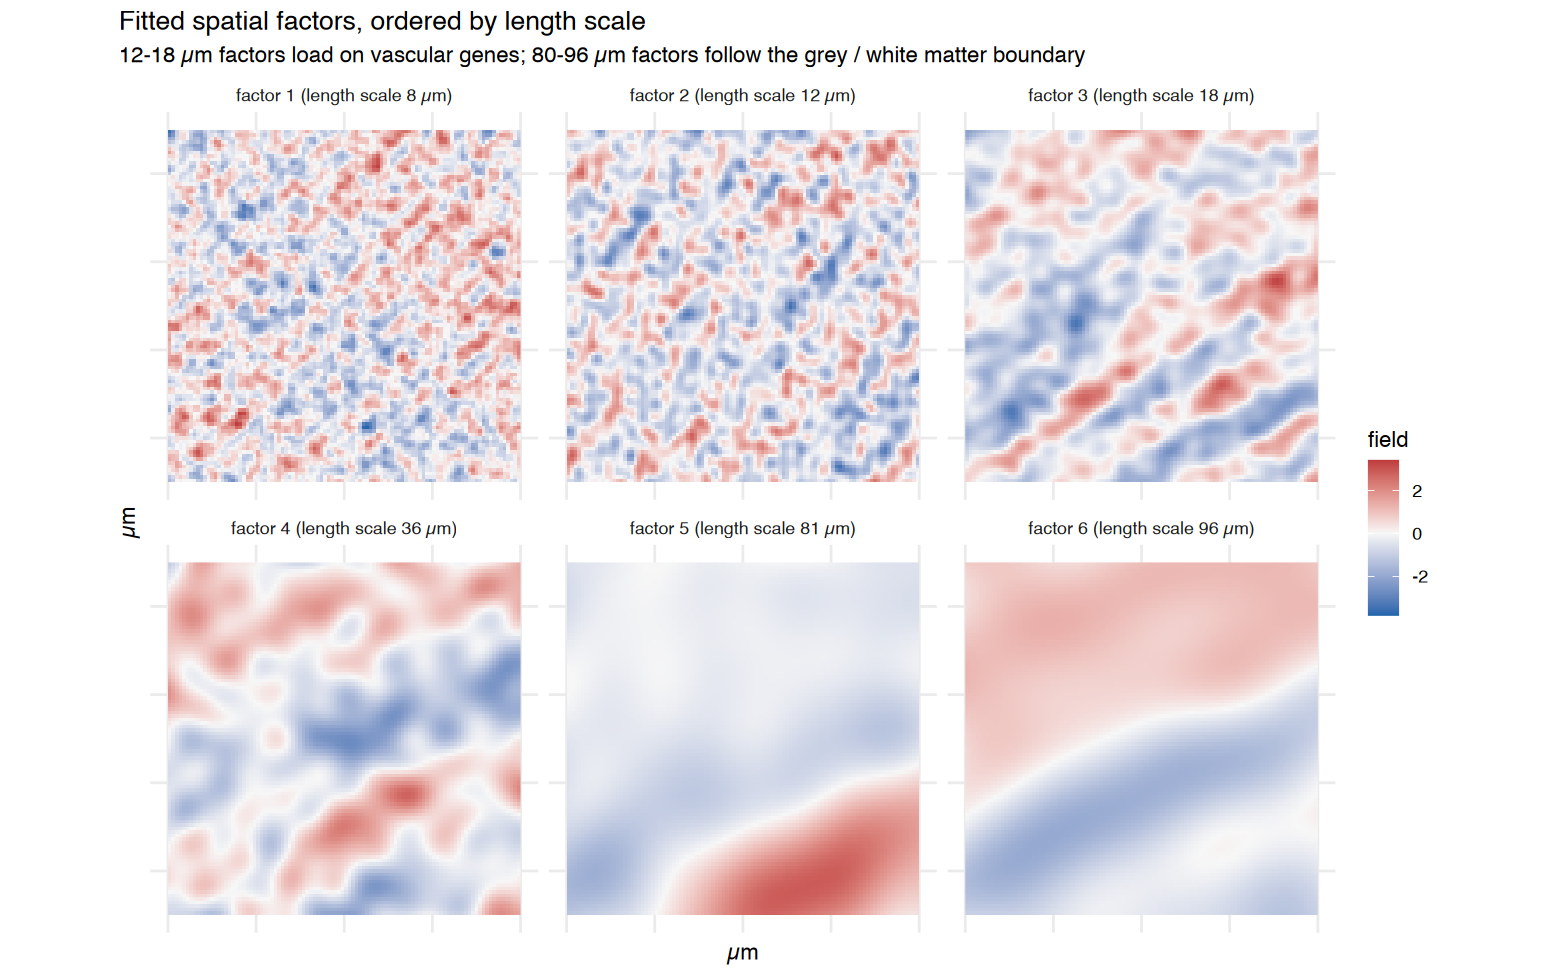

In [17]:
ord <- order(cfit$lengthscales)
fields <- do.call(rbind, lapply(ord, function(k) {
  data.frame(cb$coords[, c("x", "y")], value = cfit$field_grid[, paste0("factor", k)],
             factor = sprintf("factor %d (length scale %.0f µm)", k, cfit$lengthscales[k]))
}))
fields$factor <- factor(fields$factor, levels = unique(fields$factor))
top_genes <- vapply(ord, function(k) {
  l <- cfit$L[, k]; paste(names(sort(l, decreasing = TRUE))[1:3], collapse = ", ")
}, "")
top_genes

options(repr.plot.width = 12, repr.plot.height = 7.5)
ggplot(fields, aes(x, y, fill = value)) +
  geom_raster() +
  facet_wrap(~ factor, ncol = 3) +
  scale_fill_gradient2(low = "#2166AC", mid = "grey97", high = "#B2182B", midpoint = 0, name = "field") +
  coord_equal() + scale_y_reverse() +
  labs(title = "Fitted spatial factors, ordered by length scale",
       subtitle = "12-18 µm factors load on vascular genes; 80-96 µm factors follow the grey / white matter boundary",
       x = "µm", y = "µm") +
  theme_tut + theme(axis.text = element_blank())

method,abs(empirical - model)
<chr>,<dbl>
gaussian,1.33867127
intensity (default),0.06571323


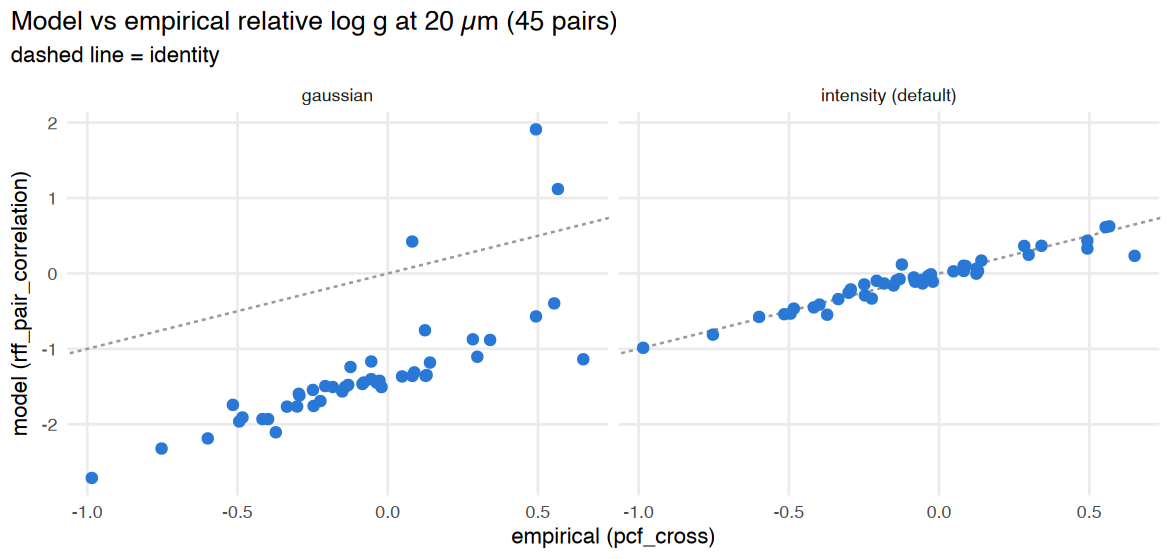

In [18]:
tt_c <- pcf_cross(cb, cb$genes, cb$genes, r_max = 50, r_step = 8)
agree <- do.call(rbind, lapply(seq_along(nm), function(i) do.call(rbind, lapply(i:length(nm), function(j) {
  e <- pcf_cross(cb, brain_sets[[nm[i]]], brain_sets[[nm[j]]], r_max = 50, r_step = 8)
  data.frame(a = nm[i], b = nm[j],
             empirical = approx(e$r, e$log_g - tt_c$log_g, xout = 20)$y,
             intensity = rff_pair_correlation(cfit, brain_sets[[nm[i]]], brain_sets[[nm[j]]], 20, "relative")$log_g,
             gaussian = rff_pair_correlation(cfit, brain_sets[[nm[i]]], brain_sets[[nm[j]]], 20, "relative",
                                             method = "gaussian")$log_g)
}))))
agree_long <- rbind(data.frame(agree[, 1:3], model = agree$intensity, method = "intensity (default)"),
                    data.frame(agree[, 1:3], model = agree$gaussian, method = "gaussian"))
aggregate(abs(empirical - model) ~ method, data = agree_long, FUN = mean)

options(repr.plot.width = 9, repr.plot.height = 4.3)
ggplot(agree_long, aes(empirical, model)) +
  geom_abline(slope = 1, intercept = 0, color = "grey60", linetype = "dashed") +
  geom_point(size = 2.2, color = "#2a78d6") +
  facet_wrap(~ method) +
  labs(title = "Model vs empirical relative log g at 20 µm (45 pairs)",
       subtitle = "dashed line = identity", x = "empirical (pcf_cross)", y = "model (rff_pair_correlation)") +
  theme_tut

With `method = "intensity"` the model reproduces the empirical estimate. The closed-form Gaussian value is far off on real tissue: vessels and meninges are sparse, line-like structures whose log-intensity is not Gaussian.

## 6. Practical guidance

1. **Start model-free.** `pcf_cross(relative = TRUE)` / `colocalization_per_sample(method = "empirical")` is fast (a whole Xenium section with 45 pairs takes 1–2 minutes), makes no distributional assumption, and is robust to cellularity differences.
2. **Read cross-type co-localization at $r \gtrsim$ one cell diameter.** At shorter distances, transcripts of the same cell dominate.
3. **Compare groups at the patient level.** Use `compare_groups(..., pair_keys = c("cluster_i", "cluster_j", "r"))`. With several sections per patient, apply `summarize_by_patient()` or use `method = "lmm"` with `patient_key`, as in the case-control tutorial.
4. **Use the model for composition and spatial scales.** `rff_pair_correlation(type = "composition")` removes the cellularity field, and the fitted length scales show at which scale each spatial program operates. With few cell types, use `offset = "smoothed_total"` with reference `offset_genes`.
5. **Limitations (experimental).** MAP fitting in R (about 1 minute per 10,000 bins and 40 genes) limits the model to regions; the Dirichlet-process spectral mixture and Gibbs sampler of the original RFLVM are not implemented yet; model-based estimates are shrunk towards 0 at short range.

In [19]:
sessionInfo()

R version 4.3.2 (2023-10-31)
Platform: aarch64-apple-darwin20 (64-bit)
Running under: macOS 26.3.1

Matrix products: default
BLAS:   /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRblas.0.dylib 
LAPACK: /Library/Frameworks/R.framework/Versions/4.3-arm64/Resources/lib/libRlapack.dylib;  LAPACK version 3.11.0

locale:
[1] en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/en_US.UTF-8

time zone: Asia/Tokyo
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] patchwork_1.1.3       ggplot2_3.4.4         spatialCooccur_0.99.2
[4] testthat_3.2.1       

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     rstudioapi_0.15.0      jsonlite_2.0.0        
  [4] magrittr_2.0.3         spatstat.utils_3.1-2   farver_2.1.1          
  [7] fs_1.6.3               vctrs_0.6.5            ROCR_1.0-11           
 [10] Cairo_1.6-2            memoise_2.0.1          spatst